# Synthetic Data দিয়ে Volume Regression Model Training

**iPhone/আসল scan ছাড়াই** volume estimation model train করার সম্পূর্ণ pipeline:

```
১. Pile Generator    → random আকৃতির pile + EXACT volume (গাণিতিকভাবে নির্ভুল)
২. Scan Simulator    → iPhone Scaniverse-এর মতো outer-shell scan বানানো
                       (hidden point removal, scan-line stripes, noise, tilt,
                        floor নেই — আসল data-র সব বৈশিষ্ট্য)
৩. Feature Pipeline  → vol_TIN + geometric statistics (real pipeline-এর সাথে identical)
৪. Training          → ExtraTrees / HistGradientBoosting / SVR তুলনা
৫. Real Calibration  → (ঐচ্ছিক) ৬৩টা real GT file দিয়ে LOO-CV + residual correction
```

**মূল ধারণা (sim-to-real):** missing floor আর occlusion-এর কারণে geometry method
systematically কম estimate করে। Synthetic data-তে আসল volume exact জানা থাকে, তাই
model হাজার হাজার উদাহরণ থেকে শিখে নেয় "উপরের shell এরকম দেখালে আসল volume এত" —
সেই bias correction যা ৬৩ sample-এ শেখা কঠিন।

**Load-shedding safe:** dataset generation ধাপে ধাপে CSV-তে save হয় — মাঝপথে বন্ধ
হলে আবার চালালে যেখানে ছিল সেখান থেকে continue করবে।


## 1 · Imports & Configuration

In [13]:
# ── Install (run once if needed) ─────────────────────────────────────────────
# pip install numpy scipy scikit-learn open3d pandas joblib tqdm matplotlib

import os, glob, time, logging
import numpy as np
import pandas as pd
import joblib
import open3d as o3d
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.spatial import Delaunay, cKDTree

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger(__name__)

In [14]:
# ── Configuration — শুধু এখানে বদলান ──────────────────────────────────────
CONFIG = {
    # ── dataset generation ───────────────────────────────────────────────────
    "n_samples"      : 30,      # কতগুলো synthetic scan বানানো হবে
    "save_every"     : 10,       # প্রতি এতগুলো sample পরে CSV-তে save (resume-safe)
    "dataset_csv"    : "synthetic_volume_dataset.csv",
    "seed"           : 42,

    # ── pile shape randomization (domain randomization) ─────────────────────
    "radius_range"   : (1.0, 6.0),    # pile-এর বিস্তার (m)
    "height_range"   : (0.5, 3.5),    # সর্বোচ্চ উচ্চতা (m)
    "n_bumps_range"  : (1, 5),        # কয়টা চূড়া (Gaussian bump)
    "grid_res"       : 128,           # exact-volume হিসাবের grid resolution

    # ── scan simulation (Scaniverse-এর মতো) ──────────────────────────────────
    "surface_points" : (30000, 90000), # shell-এ কত point (আসল: 400-800k full cloud,
                                        # কিন্তু target অংশ এর কাছাকাছি)
    "n_cameras"      : (3, 8),        # কয়টা viewpoint থেকে scan (walk-around)
    "noise_std"      : (0.003, 0.015),# measurement noise (m)
    "stripe_period"  : (0.04, 0.12),  # scan-line stripe-এর দূরত্ব (m)
    "stripe_fill"    : (0.45, 0.85),  # stripe-এ কত ভাগ point থাকে
    "tilt_deg_max"   : 8.0,           # scan-এর সর্বোচ্চ কাত (ডিগ্রি)
    "edge_dropout"   : (0.0, 0.35),   # কিনারার point হারানোর সম্ভাবনা (occlusion)
    "wall_leak_frac" : (0.0, 0.04),   # segmentation-এ দেয়াল leak-এর অনুকরণ

    # ── model training ────────────────────────────────────────────────────────
    "test_frac"      : 0.2,       # synthetic holdout ভাগ
    "model_out"      : "volume_regressor.joblib",

    # ── real-data calibration (ঐচ্ছিক) ───────────────────────────────────────
    "real_train_dir" : "../data/train",
    "real_gt_csv"    : "../data/gt_volume.csv",
    "target_class"   : 1,
}

rng_global = np.random.RandomState(CONFIG["seed"])

## 2 · Synthetic Pile Generator

Pile = কয়েকটা Gaussian bump-এর যোগফল (heightfield)। Angle-of-repose ঢাল ঠিক রাখতে
bump-এর width উচ্চতার সমানুপাতে রাখা হয়। **Exact volume** = grid integration:
$V = \sum z(x,y) \cdot \Delta A$ — এখানে কোনো অনুমান নেই, এটাই সত্য মান।

In [15]:
# ── Pile generator ────────────────────────────────────────────────────────────
def generate_pile(rng):
    """Random pile heightfield বানায়।

    গুরুত্বপূর্ণ design নিয়ম: pile-এর footprint radius bump-গুলো থেকেই derive হয়
    (center + 3×width), যাতে কিনারায় উচ্চতা ~০-তে নেমে আসে — বাস্তব pile-এর মতো।
    (আগের version-এ fixed radius-এ চওড়া bump কাটা পড়ে কিনারায় 'cliff' তৈরি হচ্ছিল,
    যা floor baseline নষ্ট করে দিত।)

    Returns:
      height_fn(x, y) -> z   : যেকোনো (x,y)-তে pile-এর উচ্চতা
      true_volume (float)    : exact volume (grid integration)
      radius (float)         : derived footprint radius
    """
    n_bumps = rng.randint(CONFIG["n_bumps_range"][0],
                          CONFIG["n_bumps_range"][1] + 1)

    # ── প্রথমে bump-গুলো বানানো ──────────────────────────────────────────────
    bumps = []
    for k in range(n_bumps):
        h = rng.uniform(*CONFIG["height_range"])
        # angle of repose: wood powder ~28-40°, width ∝ height
        w = h / np.tan(np.radians(rng.uniform(28, 40)))
        if k == 0:
            cx, cy = 0.0, 0.0                     # প্রধান bump কেন্দ্রে
        else:
            # পরের bump গুলো প্রধানটার আশেপাশে (overlap করে একটাই pile হয়)
            ang  = rng.uniform(0, 2 * np.pi)
            dist = rng.uniform(0.3, 1.2) * w
            cx, cy = dist * np.cos(ang), dist * np.sin(ang)
        bumps.append((cx, cy, h, w))

    # ── radius: সবচেয়ে দূরে-পৌঁছানো bump-এর 3σ পর্যন্ত ───────────────────────
    radius = max(np.hypot(cx, cy) + 3.0 * w for cx, cy, h, w in bumps)

    # খুব বড় pile হলে সব মাপ একসাথে scale (repose angle অক্ষুণ্ণ থাকে)
    max_r = CONFIG["radius_range"][1]
    if radius > max_r:
        s = max_r / radius
        bumps  = [(cx * s, cy * s, h * s, w * s) for cx, cy, h, w in bumps]
        radius = max_r

    def height_fn(x, y):
        """সব bump-এর মধ্যে সর্বোচ্চ উচ্চতা।"""
        z = np.zeros_like(x, dtype=np.float64)
        for cx, cy, h, w in bumps:
            d2 = (x - cx) ** 2 + (y - cy) ** 2
            z  = np.maximum(z, h * np.exp(-d2 / (2 * w ** 2)))
        return z

    # ── exact volume: dense grid integration ─────────────────────────────────
    res  = CONFIG["grid_res"]
    lin  = np.linspace(-radius, radius, res)
    gx, gy = np.meshgrid(lin, lin)
    gz   = height_fn(gx, gy)
    cell_area   = (lin[1] - lin[0]) ** 2
    true_volume = float(gz.sum() * cell_area)

    return height_fn, true_volume, radius

## 3 · Scan Simulator (Scaniverse-এর অনুকরণ)

আসল iPhone scan-এর বৈশিষ্ট্যগুলো ধাপে ধাপে প্রয়োগ করা হয়:

| আসল data-র বৈশিষ্ট্য | Simulation |
|---|---|
| শুধু outer shell (ভেতর ফাঁপা) | surface sampling — কেবল উপরিতল |
| Floor point নেই | floor generate-ই করা হয় না |
| আড়ালের অংশ scan হয়নি | Open3D hidden point removal, একাধিক camera |
| Scan-line stripes (ডোরাকাটা) | random দিকের stripe mask |
| Measurement noise | Gaussian noise (৩-১৫ মিমি) |
| Scan কাত (tilted) | random rotation (০-৮°) |
| কিনারায় sparse | edge dropout |
| Segmentation wall leak | সামান্য খাড়া-plane points যোগ (ঐচ্ছিক) |

In [16]:
# ── Scan simulator ────────────────────────────────────────────────────────────
def _rotation_matrix(rng, max_deg):
    """ছোট random tilt-এর rotation matrix।"""
    ax = np.radians(rng.uniform(-max_deg, max_deg))
    ay = np.radians(rng.uniform(-max_deg, max_deg))
    Rx = np.array([[1, 0, 0],
                   [0, np.cos(ax), -np.sin(ax)],
                   [0, np.sin(ax),  np.cos(ax)]])
    Ry = np.array([[ np.cos(ay), 0, np.sin(ay)],
                   [0, 1, 0],
                   [-np.sin(ay), 0, np.cos(ay)]])
    return Ry @ Rx


def simulate_scan(height_fn, radius, rng):
    """একটা pile-এর Scaniverse-সদৃশ outer-shell scan তৈরি করে।
    Returns points[N,3] — শুধু pile-এর দৃশ্যমান উপরিতল, floor নেই।"""

    # ── 1. surface sampling: pile-এর উপরিতলে point ──────────────────────────
    n_pts = rng.randint(*CONFIG["surface_points"])
    # sqrt-uniform radial sampling → ক্ষেত্রফল-সমান বিস্তার
    r     = radius * np.sqrt(rng.uniform(0, 1, n_pts))
    theta = rng.uniform(0, 2 * np.pi, n_pts)
    x, y  = r * np.cos(theta), r * np.sin(theta)
    z     = height_fn(x, y)
    keep  = z > 0.02                      # শূন্য-উচ্চতার (pile-এর বাইরে) point বাদ
    pts   = np.column_stack([x[keep], y[keep], z[keep]])
    if len(pts) < 500:
        return None

    # ── 2. hidden point removal: একাধিক camera থেকে visibility ─────────────
    # walk-around scan: pile-এর চারদিক থেকে কয়েকটা viewpoint;
    # যেসব point কোনো viewpoint থেকেই দেখা যায় না (গভীর খাঁজ) → বাদ
    n_cam   = rng.randint(*CONFIG["n_cameras"])
    visible = np.zeros(len(pts), bool)
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    diameter = float(np.linalg.norm(pts.max(0) - pts.min(0)))
    for i in range(n_cam):
        ang = 2 * np.pi * i / n_cam + rng.uniform(0, 0.5)
        cam = np.array([np.cos(ang) * radius * 2.2,
                        np.sin(ang) * radius * 2.2,
                        pts[:, 2].max() * rng.uniform(1.2, 2.5)])
        try:
            _, idx = pcd.hidden_point_removal(cam, diameter * 100)
            visible[np.asarray(idx)] = True
        except Exception:
            visible[:] = True             # HPR ব্যর্থ হলে সবাই দৃশ্যমান ধরা
    pts = pts[visible]
    if len(pts) < 500:
        return None

    # ── 3. scan-line stripes (Scaniverse-এর ডোরাকাটা pattern) ───────────────
    period = rng.uniform(*CONFIG["stripe_period"])
    fill   = rng.uniform(*CONFIG["stripe_fill"])
    stripe_dir = rng.uniform(0, np.pi)    # stripe-এর random দিক
    proj   = pts[:, 0] * np.cos(stripe_dir) + pts[:, 1] * np.sin(stripe_dir)
    keep   = (proj % period) < (period * fill)
    if keep.sum() > 500:
        pts = pts[keep]

    # ── 4. edge dropout (কিনারায় occlusion/sparse density) ──────────────────
    drop_p = rng.uniform(*CONFIG["edge_dropout"])
    if drop_p > 0:
        r_norm = np.linalg.norm(pts[:, :2], axis=1) / radius
        drop   = (r_norm > 0.7) & (rng.uniform(0, 1, len(pts)) < drop_p)
        pts    = pts[~drop]

    # ── 5. measurement noise ──────────────────────────────────────────────────
    noise = rng.uniform(*CONFIG["noise_std"])
    pts   = pts + rng.normal(0, noise, pts.shape)

    # ── 6. wall-leak contamination (segmentation ভুলের অনুকরণ, ঐচ্ছিক) ───────
    leak = rng.uniform(*CONFIG["wall_leak_frac"])
    if leak > 0.001:
        n_leak = int(len(pts) * leak)
        side   = rng.uniform(0, 2 * np.pi)
        wx     = np.cos(side) * radius * rng.uniform(0.8, 1.05)
        wy     = np.sin(side) * radius * rng.uniform(0.8, 1.05)
        wall = np.column_stack([
            np.full(n_leak, wx) + rng.normal(0, 0.02, n_leak),
            np.full(n_leak, wy) + rng.normal(0, 0.02, n_leak),
            rng.uniform(0, pts[:, 2].max() * 1.2, n_leak)])
        pts = np.vstack([pts, wall])

    # ── 7. random tilt (scan হেলানো) ─────────────────────────────────────────
    R   = _rotation_matrix(rng, CONFIG["tilt_deg_max"])
    pts = pts @ R.T

    return pts

## 4 · Feature Pipeline (real pipeline-এর সাথে identical)

**সবচেয়ে গুরুত্বপূর্ণ নিয়ম:** synthetic আর real — দুই ক্ষেত্রেই feature extraction
**হুবহু এক** হতে হবে, নইলে sim-to-real transfer কাজ করবে না। তাই এখানে benchmark-এর
`vol_TIN` (SOR → DBSCAN cluster → TIN) হুবহু কপি করা হয়েছে, তার সাথে ১২টা geometric
statistic।

In [17]:
# ── vol_TIN (benchmark v7-এর সাথে identical) ─────────────────────────────────
def sor_filter(pts, k=16, std_ratio=2.0):
    pts = np.asarray(pts, np.float64)
    if len(pts) <= k + 1:
        return pts
    tree = cKDTree(pts)
    d, _ = tree.query(pts, k=k + 1)
    mean_dist = d[:, 1:].mean(axis=1)
    thr = mean_dist.mean() + std_ratio * mean_dist.std()
    return pts[mean_dist <= thr]


def extract_main_cluster(pts, eps=0.15, min_samples=8):
    pts = np.asarray(pts, np.float64)
    if len(pts) < min_samples * 2:
        return pts
    try:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        labels = np.asarray(pcd.cluster_dbscan(eps=eps, min_points=min_samples))
        valid = labels[labels >= 0]
        if valid.size == 0:
            return pts
        main = np.bincount(valid).argmax()
        res  = pts[labels == main]
        return res if len(res) >= min_samples else pts
    except Exception:
        return pts


def tin_integrate(pts, floor_pct=0.5):
    pts = np.asarray(pts, np.float64)
    if len(pts) < 4:
        return float("nan")
    floor_z = np.percentile(pts[:, 2], floor_pct)
    h  = pts[:, 2] - floor_z
    xy = pts[:, :2]
    try:
        tri = Delaunay(xy)
    except Exception:
        return float("nan")
    t = tri.simplices
    p0, p1, p2 = xy[t[:, 0]], xy[t[:, 1]], xy[t[:, 2]]
    h0, h1, h2 = h[t[:, 0]], h[t[:, 1]], h[t[:, 2]]
    cross  = ((p1[:, 0] - p0[:, 0]) * (p2[:, 1] - p0[:, 1])
             - (p1[:, 1] - p0[:, 1]) * (p2[:, 0] - p0[:, 0]))
    area2d = np.abs(cross) / 2.0
    mean_h = (h0 + h1 + h2) / 3.0
    valid  = mean_h > 0
    return float(np.sum(area2d[valid] * mean_h[valid]))

In [18]:
# ── Feature extraction: ১২টা geometric statistic + vol_TIN ──────────────────
FEATURE_NAMES = [
    "vol_tin",           # TIN integration estimate (সবচেয়ে শক্তিশালী feature)
    "hull_volume",       # convex hull volume (উর্ধ্বসীমা)
    "footprint_area",    # 2D convex hull area
    "max_height",        # floor baseline থেকে সর্বোচ্চ উচ্চতা
    "mean_height",
    "height_std",
    "bbox_dx", "bbox_dy", "bbox_dz",
    "n_points",
    "point_density",     # points / footprint_area
    "z_p25", "z_p50", "z_p75",   # height percentiles
]

def detilt(pts, base_pct=15):
    """De-tilt normalization: pile-এর নিচের প্রান্ত-বলয় (base rim) মোটামুটি
    ground plane-এ থাকে। সেই বলয়ে least-squares plane fit করে পুরো cloud-কে
    ঘুরিয়ে plane-টাকে অনুভূমিক করা হয়। Scan হেলানো থাকলে (real/synthetic
    দুটোতেই হয়) TIN-এর height আর footprint দুটোই ঠিক হয়ে যায়।"""
    pts = np.asarray(pts, np.float64)
    z_thr = np.percentile(pts[:, 2], base_pct)
    base  = pts[pts[:, 2] <= z_thr]
    if len(base) < 50:
        return pts
    # least-squares plane: z = a*x + b*y + c
    A = np.c_[base[:, 0], base[:, 1], np.ones(len(base))]
    try:
        (a, b, _), *_ = np.linalg.lstsq(A, base[:, 2], rcond=None)
    except Exception:
        return pts
    n = np.array([-a, -b, 1.0]); n /= np.linalg.norm(n)
    # rotation that maps n → +z (Rodrigues)
    v = np.cross(n, [0., 0., 1.]); s = np.linalg.norm(v)
    if s < 1e-8:
        return pts
    vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
    R  = np.eye(3) + vx + vx @ vx * ((1 - n[2]) / s ** 2)
    return pts @ R.T


def extract_features(pts):
    """Segmented target points → feature vector (real ও synthetic-এ identical)।
    Returns dict বা None (খুব ছোট cloud হলে)।"""
    pts = np.asarray(pts, np.float64)
    if len(pts) < 50:
        return None

    # pre-processing: বাস্তব pipeline-এর মতোই SOR → largest cluster → de-tilt
    pts = sor_filter(pts)
    pts = extract_main_cluster(pts)
    if len(pts) < 50:
        return None
    pts = detilt(pts)

    # TIN volume
    v_tin = tin_integrate(pts, floor_pct=0.5)
    if not np.isfinite(v_tin) or v_tin <= 0:
        return None

    # heights above floor baseline
    floor_z = np.percentile(pts[:, 2], 0.5)
    h = pts[:, 2] - floor_z

    # convex hull volume + footprint
    from scipy.spatial import ConvexHull
    try:
        hull3d = ConvexHull(pts)
        hull_v = float(hull3d.volume)
    except Exception:
        hull_v = float("nan")
    try:
        hull2d = ConvexHull(pts[:, :2])
        area   = float(hull2d.volume)     # 2D-তে .volume = area
    except Exception:
        area = float("nan")

    bbox = pts.max(0) - pts.min(0)

    return {
        "vol_tin"       : v_tin,
        "hull_volume"   : hull_v,
        "footprint_area": area,
        "max_height"    : float(h.max()),
        "mean_height"   : float(h.mean()),
        "height_std"    : float(h.std()),
        "bbox_dx"       : float(bbox[0]),
        "bbox_dy"       : float(bbox[1]),
        "bbox_dz"       : float(bbox[2]),
        "n_points"      : float(len(pts)),
        "point_density" : float(len(pts) / max(area, 1e-6)),
        "z_p25"         : float(np.percentile(h, 25)),
        "z_p50"         : float(np.percentile(h, 50)),
        "z_p75"         : float(np.percentile(h, 75)),
    }

## 5 · Dataset Generation (resume-safe)

প্রতি `save_every` sample পরে CSV-তে save হয়। Load-shedding-এ বন্ধ হলে আবার চালান —
আগের গুলো ফাইল থেকে পড়ে ঠিক যেখানে ছিল সেখান থেকে continue করবে।

In [19]:
# ── Dataset generation loop ───────────────────────────────────────────────────
def generate_dataset():
    csv_path = CONFIG["dataset_csv"]

    # ── resume: আগের ফাইল থাকলে সেখান থেকে continue ─────────────────────────
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        done = len(df_existing)
        log.info(f"Resume: {done} sample আগেই তৈরি — {CONFIG['n_samples'] - done} বাকি")
    else:
        df_existing = pd.DataFrame()
        done = 0

    if done >= CONFIG["n_samples"]:
        log.info("Dataset already complete.")
        return pd.read_csv(csv_path)

    rows  = []
    pbar  = tqdm(total=CONFIG["n_samples"], initial=done, desc="generating")
    rng   = np.random.RandomState(CONFIG["seed"] + done)   # resume-এও ভিন্ন seed
    made  = done
    t0    = time.time()

    while made < CONFIG["n_samples"]:
        # ── এক sample: pile → scan → features ────────────────────────────────
        height_fn, true_vol, radius = generate_pile(rng)
        pts = simulate_scan(height_fn, radius, rng)
        if pts is None:
            continue
        feat = extract_features(pts)
        if feat is None:
            continue

        feat["true_volume"] = true_vol
        rows.append(feat)
        made += 1
        pbar.update(1)

        # ── periodic save (load-shedding safe) ────────────────────────────────
        if len(rows) >= CONFIG["save_every"]:
            df_new = pd.DataFrame(rows)
            df_all = pd.concat([df_existing, df_new], ignore_index=True) \
                     if not df_existing.empty else df_new
            df_all.to_csv(csv_path, index=False)
            df_existing = df_all
            rows = []
            log.info(f"  saved {made}/{CONFIG['n_samples']} "
                     f"({(time.time()-t0)/60:.1f} min elapsed)")

    # শেষ অবশিষ্ট rows save
    if rows:
        df_new = pd.DataFrame(rows)
        df_all = pd.concat([df_existing, df_new], ignore_index=True) \
                 if not df_existing.empty else df_new
        df_all.to_csv(csv_path, index=False)

    pbar.close()
    log.info(f"Dataset complete: {csv_path}")
    return pd.read_csv(csv_path)


DATASET = generate_dataset()
print(f"\nDataset: {len(DATASET)} samples")
DATASET.describe().round(3)

2026-07-10 16:12:54,093 | INFO | Resume: 30 sample আগেই তৈরি — 0 বাকি
2026-07-10 16:12:54,093 | INFO | Dataset already complete.



Dataset: 30 samples


,vol_tin,hull_volume,footprint_area,max_height,mean_height,height_std,bbox_dx,bbox_dy,bbox_dz,n_points,point_density,z_p25,z_p50,z_p75,true_volume
count,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000
mean,24.712,40.276,75.836,1.272,0.331,0.298,9.776,9.727,1.295,24829.333,351.002,0.103,0.215,0.496,22.657
std,9.547,17.741,21.177,0.245,0.056,0.050,1.423,1.480,0.248,8577.560,173.632,0.038,0.044,0.076,7.958
min,4.080,7.451,24.374,0.726,0.182,0.154,5.606,5.586,0.746,10857.000,141.429,0.042,0.129,0.275,4.240
25%,17.630,26.190,60.025,1.167,0.301,0.264,8.771,8.631,1.186,18004.500,250.449,0.078,0.188,0.453,16.315
50%,25.156,37.082,77.656,1.257,0.332,0.303,10.057,9.843,1.279,24456.500,345.756,0.099,0.213,0.505,23.593
75%,31.012,56.457,96.784,1.450,0.361,0.328,11.066,11.239,1.470,31805.000,392.178,0.121,0.237,0.531,29.915
max,44.530,70.059,107.915,1.717,0.454,0.393,11.769,11.763,1.753,39923.000,1018.701,0.212,0.344,0.642,38.158


## 6 · Training — তিনটা regressor তুলনা

Target: `log1p(true_volume)` — ছোট-বড় pile-এর scale পার্থক্য কমায়, training স্থিতিশীল।
Metric: **MAPE** (mean absolute percentage error) — আপনার <5% লক্ষ্যের সরাসরি মাপ।

In [20]:
# ── Training ──────────────────────────────────────────────────────────────────
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

X = DATASET[FEATURE_NAMES].values
y = DATASET["true_volume"].values
y_log = np.log1p(y)

X_tr, X_te, ylog_tr, ylog_te, y_tr, y_te = train_test_split(
    X, y_log, y, test_size=CONFIG["test_frac"], random_state=CONFIG["seed"])

MODELS = {
    "ExtraTrees": ExtraTreesRegressor(400, n_jobs=-1,
                                      random_state=CONFIG["seed"]),
    "HistGB"    : HistGradientBoostingRegressor(max_iter=500,
                                                random_state=CONFIG["seed"]),
    "SVR"       : make_pipeline(StandardScaler(), SVR(C=10.0, epsilon=0.01)),
}

results = {}
for name, model in MODELS.items():
    model.fit(X_tr, ylog_tr)
    pred_v = np.expm1(model.predict(X_te))
    mape   = float(np.mean(np.abs(pred_v - y_te) / np.clip(y_te, 1e-9, None)) * 100)
    mae    = float(np.mean(np.abs(pred_v - y_te)))
    results[name] = {"model": model, "mape_pct": mape, "mae_m3": mae}
    log.info(f"{name:12s} | MAPE = {mape:5.2f}%  |  MAE = {mae:.3f} m³")

# baseline তুলনা: শুধু raw TIN কত ভুল করত?
tin_only = X_te[:, FEATURE_NAMES.index("vol_tin")]
tin_mape = float(np.mean(np.abs(tin_only - y_te) / np.clip(y_te, 1e-9, None)) * 100)
log.info(f"{'raw vol_TIN':12s} | MAPE = {tin_mape:5.2f}%  (baseline, model ছাড়া)")

BEST_NAME  = min(results, key=lambda k: results[k]["mape_pct"])
BEST_MODEL = results[BEST_NAME]["model"]
log.info(f"\nBest: {BEST_NAME}  (MAPE {results[BEST_NAME]['mape_pct']:.2f}%)")

2026-07-10 16:12:54,345 | INFO | ExtraTrees   | MAPE =  5.05%  |  MAE = 1.087 m³
2026-07-10 16:12:54,441 | INFO | HistGB       | MAPE = 25.30%  |  MAE = 5.079 m³
2026-07-10 16:12:54,444 | INFO | SVR          | MAPE =  6.57%  |  MAE = 1.601 m³
2026-07-10 16:12:54,444 | INFO | raw vol_TIN  | MAPE = 13.83%  (baseline, model ছাড়া)
2026-07-10 16:12:54,445 | INFO | 
Best: ExtraTrees  (MAPE 5.05%)


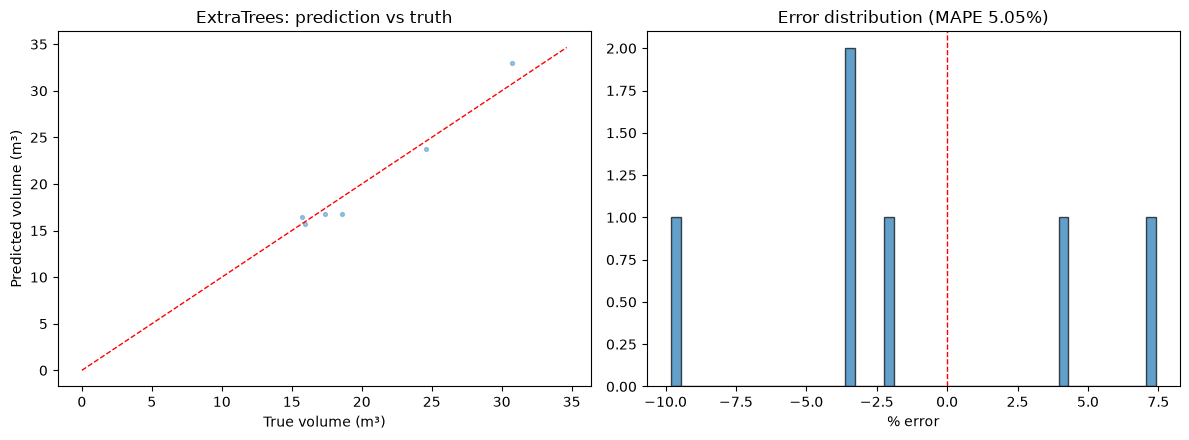

In [21]:
# ── Error visualization ───────────────────────────────────────────────────────
pred_best = np.expm1(BEST_MODEL.predict(X_te))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_te, pred_best, s=8, alpha=0.4)
lim = [0, max(y_te.max(), pred_best.max()) * 1.05]
axes[0].plot(lim, lim, "r--", lw=1)
axes[0].set_xlabel("True volume (m³)")
axes[0].set_ylabel("Predicted volume (m³)")
axes[0].set_title(f"{BEST_NAME}: prediction vs truth")

pct_err = (pred_best - y_te) / y_te * 100
axes[1].hist(pct_err, bins=50, edgecolor="k", alpha=0.7)
axes[1].axvline(0, color="r", ls="--", lw=1)
axes[1].set_xlabel("% error")
axes[1].set_title(f"Error distribution (MAPE {results[BEST_NAME]['mape_pct']:.2f}%)")
plt.tight_layout()
plt.show()

In [22]:
# ── Save final model ─────────────────────────────────────────────────────────
joblib.dump({
    "model"         : BEST_MODEL,
    "model_name"    : BEST_NAME,
    "feature_names" : FEATURE_NAMES,
    "target"        : "log1p(volume_m3)",
    "synthetic_mape": results[BEST_NAME]["mape_pct"],
}, CONFIG["model_out"])
log.info(f"Model saved → {CONFIG['model_out']}")

2026-07-10 16:12:54,709 | INFO | Model saved → volume_regressor.joblib


## 7 · Inference Function

Real pipeline-এ ব্যবহারের জন্য: segmented target points → predicted volume।

In [23]:
# ── Inference: segmented target points → volume ──────────────────────────────
def predict_volume(target_points, model_path=None):
    """Segmentation-এর পরে target points দিয়ে volume predict করে।
    Returns (volume_m3, features_dict) বা (nan, None)।"""
    blob  = joblib.load(model_path or CONFIG["model_out"])
    feats = extract_features(target_points)
    if feats is None:
        return float("nan"), None
    x = np.array([[feats[k] for k in blob["feature_names"]]])
    v = float(np.expm1(blob["model"].predict(x)[0]))
    return v, feats


# দ্রুত sanity check: একটা নতুন synthetic pile-এ
_rng = np.random.RandomState(999)
_hf, _tv, _rad = generate_pile(_rng)
_pts = simulate_scan(_hf, _rad, _rng)
_pv, _ = predict_volume(_pts)
print(f"sanity check — true: {_tv:.3f} m³ | predicted: {_pv:.3f} m³ "
      f"| error: {abs(_pv-_tv)/_tv*100:.2f}%")

sanity check — true: 7.712 m³ | predicted: 7.490 m³ | error: 2.88%


## 8 · Real-Data Calibration (ঐচ্ছিক — ৬৩টা GT file থাকলে)

Synthetic-trained model real data-তে কেমন করে যাচাই + residual correction।
Real file-এ target mask হিসেবে GT label (`classification == target_class`) ব্যবহার হয়।
**Leave-One-Out CV** — ৬৩ sample-এর প্রতিটাই কাজে লাগে, honest error estimate।

In [24]:
# ── Real-data calibration (চালান শুধু real data থাকলে) ──────────────────────
def calibrate_on_real():
    import laspy
    from sklearn.model_selection import LeaveOneOut
    from sklearn.linear_model import Ridge

    files = sorted(glob.glob(os.path.join(CONFIG["real_train_dir"], "*.las")) +
                   glob.glob(os.path.join(CONFIG["real_train_dir"], "*.laz")))
    if not files or not os.path.exists(CONFIG["real_gt_csv"]):
        log.warning("Real data/GT পাওয়া যায়নি — calibration skip। "
                    "(এই cell পরে data থাকলে চালালেই হবে)")
        return

    gt_df = pd.read_csv(CONFIG["real_gt_csv"])
    fname_col = next(c for c in gt_df.columns
                     if not pd.api.types.is_numeric_dtype(gt_df[c]))
    vol_col   = next(c for c in gt_df.columns
                     if pd.api.types.is_numeric_dtype(gt_df[c]))
    gt = {os.path.splitext(os.path.basename(str(r[fname_col])))[0]: float(r[vol_col])
          for _, r in gt_df.iterrows()}

    # ── প্রতিটা real file → synthetic-model prediction ───────────────────────
    rows = []
    for path in tqdm(files, desc="real files"):
        name = os.path.splitext(os.path.basename(path))[0]
        if name not in gt:
            continue
        las = laspy.read(path)
        pts = np.column_stack([np.asarray(las.x), np.asarray(las.y),
                               np.asarray(las.z)])
        if "classification" not in las.point_format.dimension_names:
            continue
        lbl  = np.asarray(las.classification)
        tgt  = pts[lbl == CONFIG["target_class"]]
        v_pred, feats = predict_volume(tgt)
        if feats is None:
            continue
        rows.append({"file": name, "gt": gt[name], "syn_pred": v_pred,
                     **{k: feats[k] for k in FEATURE_NAMES}})

    dfr = pd.DataFrame(rows)
    if len(dfr) < 5:
        log.warning("যথেষ্ট real sample নেই — calibration skip")
        return

    syn_mape = float(np.mean(np.abs(dfr.syn_pred - dfr.gt) / dfr.gt) * 100)
    log.info(f"\nSynthetic model on REAL data: MAPE = {syn_mape:.2f}%  "
             f"({len(dfr)} files)")

    # ── residual correction: syn_pred → gt (LOO-CV) ──────────────────────────
    # ছোট Ridge model শুধু bias-টা ঠিক করে; বড় model ৬৩ sample-এ overfit করত
    Xc = np.log1p(dfr[["syn_pred"] + FEATURE_NAMES].values)
    yc = np.log1p(dfr["gt"].values)

    loo_preds = np.zeros(len(dfr))
    for tr, te in LeaveOneOut().split(Xc):
        ridge = Ridge(alpha=1.0).fit(Xc[tr], yc[tr])
        loo_preds[te] = ridge.predict(Xc[te])
    cal_v    = np.expm1(loo_preds)
    cal_mape = float(np.mean(np.abs(cal_v - dfr.gt) / dfr.gt) * 100)
    log.info(f"After calibration (LOO-CV):   MAPE = {cal_mape:.2f}%")

    # ── final calibration model save (সব real data দিয়ে fit) ────────────────
    final_ridge = Ridge(alpha=1.0).fit(Xc, yc)
    joblib.dump({"ridge": final_ridge, "feature_names": FEATURE_NAMES},
                "volume_calibration.joblib")
    log.info("Calibration model saved → volume_calibration.joblib")

    dfr["cal_pred"] = cal_v
    dfr["pct_err"]  = ((cal_v - dfr.gt) / dfr.gt * 100).round(2)
    display(dfr[["file", "gt", "syn_pred", "cal_pred", "pct_err"]].round(3))

calibrate_on_real()

real files:   0%|          | 0/45 [00:00<?, ?it/s]

TypeError: unsupported operand type(s) for -: 'float' and 'method'